# Custom Agent Graphs [Step 4 - Building ReAct from Scratch, Full Control]

> **MLCourse - Agentic AI - LangGraph**

This notebook builds a complete ReAct agent from scratch without using
prebuilt components like ToolNode or tools_condition. We implement custom
state, custom routing, and custom tool execution for full control over
the graph topology.

### 1. Setup and Imports


In [1]:
import os
import math
import json
import datetime
import warnings
warnings.filterwarnings("ignore")
from dotenv import load_dotenv
load_dotenv()

False

### 2. Initialize the LLM


In [2]:
from langchain_ollama import ChatOllama
llm = ChatOllama(model="llama3.1:8b", temperature=0)
print("LLM initialized:", llm.model)

LLM initialized: llama3.1:8b


### 3. Define Tools


In [3]:
from langchain_core.tools import tool

@tool
def calculator(expression: str) -> str:
    """Evaluate a mathematical expression. Supports +, -, *, /, **, sqrt, sin, cos, log, pi, e."""
    allowed = {
        "sqrt": math.sqrt, "sin": math.sin, "cos": math.cos,
        "log": math.log, "pi": math.pi, "e": math.e,
    }
    try:
        result = eval(expression, {"__builtins__": {}}, allowed)
        return json.dumps({"result": result})
    except Exception as ex:
        return json.dumps({"error": str(ex)})

@tool
def get_weather(city: str) -> str:
    """Get weather for a city. Returns temp and conditions."""
    data = {
        "london": {"temp": 15, "cond": "Cloudy"},
        "paris": {"temp": 18, "cond": "Rainy"},
        "tokyo": {"temp": 28, "cond": "Sunny"},
    }
    key = city.lower().strip()
    if key in data:
        return json.dumps({"city": city, **data[key]})
    return json.dumps({"error": f"No data for '{city}'"})

@tool
def get_current_time() -> str:
    """Get the current date and time."""
    return datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

@tool
def text_analysis(text: str) -> str:
    """Analyze text: word count, char count, sentence count."""
    words = text.split()
    sentences = [s.strip() for s in text.replace("!", ".").replace("?", ".").split(".") if s.strip()]
    return json.dumps({
        "word_count": len(words),
        "char_count": len(text),
        "sentence_count": len(sentences),
    })

tools = [calculator, get_weather, get_current_time, text_analysis]
tool_map = {t.name: t for t in tools}
print(f"Registered {len(tools)} tools: {list(tool_map.keys())}")

Registered 4 tools: ['calculator', 'get_weather', 'get_current_time', 'text_analysis']


### 4. Bind Tools to LLM


In [4]:
llm_with_tools = llm.bind_tools(tools)
print("Tools bound to LLM.")

Tools bound to LLM.


### 5. Define Custom State
Full control over what the state tracks.

In [5]:
from typing import TypedDict, Annotated, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage

class AgentState(TypedDict):
    """Custom state with full control over tracked data."""
    messages: Annotated[list[BaseMessage], "Conversation messages"]
    iteration: int
    max_iterations: int
    tool_call_count: int
    status: str  # "running", "tool_error", "completed", "max_iterations"
    trace: list[str]  # execution trace for debugging

### 6. Custom Agent Node (No Prebuilt)
Full control over how the agent reasons and formats its response.

In [6]:
def custom_agent_node(state: AgentState) -> dict:
    """Custom agent node: calls LLM, tracks iteration, updates trace."""
    messages = state["messages"]
    iteration = state.get("iteration", 0)
    max_iter = state.get("max_iterations", 5)
    trace = state.get("trace", [])

    # Check iteration limit before calling LLM
    if iteration >= max_iter:
        return {
            "status": "max_iterations",
            "trace": trace + [f"Iteration {iteration}: max reached, stopping"],
        }

    # Call LLM
    response = llm_with_tools.invoke(messages)
    new_trace = trace + [f"Iteration {iteration + 1}: agent called LLM"]

    return {
        "messages": [response],
        "iteration": iteration + 1,
        "tool_call_count": state.get("tool_call_count", 0),
        "status": "running",
        "trace": new_trace,
    }

### 7. Custom Tool Executor (No ToolNode)
We manually parse tool calls and execute them. Full control over
error handling, logging, and fallback behavior.

In [7]:
from langchain_core.messages import AIMessage, ToolMessage

def custom_tool_executor(state: AgentState) -> dict:
    """Custom tool executor: manually handles tool calls with error handling."""
    messages = state["messages"]
    trace = state.get("trace", [])
    tool_call_count = state.get("tool_call_count", 0)

    # Find the last AI message with tool calls
    last_ai_msg = None
    for msg in reversed(messages):
        if isinstance(msg, AIMessage) and msg.tool_calls:
            last_ai_msg = msg
            break

    if not last_ai_msg:
        return {
            "status": "completed",
            "trace": trace + ["No tool calls found in last AI message"],
        }

    new_messages = []
    new_trace = list(trace)

    for tc in last_ai_msg.tool_calls:
        tool_name = tc["name"]
        tool_args = tc["args"]
        tool_id = tc["id"]

        new_trace.append(f"Executing: {tool_name}({tool_args})")

        # Look up and execute the tool
        if tool_name in tool_map:
            try:
                result = tool_map[tool_name].invoke(tool_args)
                content = result if isinstance(result, str) else json.dumps(result)
                new_messages.append(ToolMessage(content=content, tool_call_id=tool_id))
                new_trace.append(f"  Result: {content[:100]}")
            except Exception as ex:
                error_content = json.dumps({"error": str(ex), "tool": tool_name})
                new_messages.append(ToolMessage(content=error_content, tool_call_id=tool_id))
                new_trace.append(f"  Error: {str(ex)}")
        else:
            error_content = json.dumps({"error": f"Unknown tool: {tool_name}"})
            new_messages.append(ToolMessage(content=error_content, tool_call_id=tool_id))
            new_trace.append(f"  Error: unknown tool '{tool_name}'")

    return {
        "messages": new_messages,
        "tool_call_count": tool_call_count + len(last_ai_msg.tool_calls),
        "trace": new_trace,
    }

### 8. Custom Router (No tools_condition)
We implement our own routing logic with full control.

In [8]:
def custom_router(state: AgentState) -> Literal["tools", "summarize", "__end__"]:
    """Custom router: checks tool calls, iteration limit, and error state."""
    last_msg = state["messages"][-1]
    iteration = state.get("iteration", 0)
    max_iter = state.get("max_iterations", 5)
    status = state.get("status", "running")

    # If max iterations reached, stop
    if iteration >= max_iter:
        print(f"  [Router] Max iterations ({max_iter}) reached.")
        return "__end__"

    # If tool error occurred, try to summarize
    if status == "tool_error":
        print(f"  [Router] Tool error detected, routing to summarize.")
        return "summarize"

    # If last message has tool calls, execute tools
    if isinstance(last_msg, AIMessage) and last_msg.tool_calls:
        print(f"  [Router] {len(last_msg.tool_calls)} tool call(s) detected.")
        return "tools"

    # Otherwise, the agent is done
    print(f"  [Router] No tool calls. Agent finished.")
    return "__end__"

### 9. Summarize Node (Optional Enhancement)
A dedicated node that formats the final response.

In [9]:
def summarize_node(state: AgentState) -> dict:
    """Summarize the conversation into a clean final answer."""
    messages = state["messages"]
    trace = state.get("trace", [])

    # Build context from tool results
    tool_results = []
    for msg in messages:
        if isinstance(msg, ToolMessage):
            tool_results.append(msg.content)

    summary_context = "\n".join(tool_results) if tool_results else "No tool results."

    return {
        "messages": [AIMessage(content=f"Summary based on tool results:\n{summary_context}")],
        "status": "completed",
        "trace": trace + ["Summary generated"],
    }

### 10. Build the Custom Graph from Scratch
No prebuilt components. Full control over topology.

In [10]:
from langgraph.graph import StateGraph, END

graph_builder = StateGraph(AgentState)

# Add all nodes
graph_builder.add_node("agent", custom_agent_node)
graph_builder.add_node("tools", custom_tool_executor)
graph_builder.add_node("summarize", summarize_node)

# Set entry point
graph_builder.set_entry_point("agent")

# Add conditional routing (custom, not tools_condition)
graph_builder.add_conditional_edges(
    "agent",
    custom_router,
    {
        "tools": "tools",
        "summarize": "summarize",
        "__end__": END,
    },
)

# Tools loop back to agent
graph_builder.add_edge("tools", "agent")

# Summarize goes to END
graph_builder.add_edge("summarize", END)

### 11. Compile and Visualize


Custom agent graph compiled.


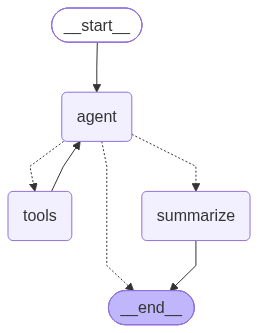

In [11]:
graph = graph_builder.compile()
print("Custom agent graph compiled.")

from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print("Graph structure:")
    print("  Entry -> agent")
    print("  agent -> [custom_router] -> tools / summarize / END")
    print("  tools -> agent (loop)")
    print("  summarize -> END")
    print("  Iteration guard + error handling + execution trace")

### 12. Run: Simple Calculator Query


In [12]:
print("=== Test 1: Calculator ===")
result = graph.invoke({
    "messages": [{"role": "user", "content": "What is sqrt(256) + 3.14?"}],
    "iteration": 0,
    "max_iterations": 5,
    "tool_call_count": 0,
    "status": "running",
    "trace": [],
})
print()
print("--- Trace ---")
for t in result["trace"]:
    print(f"  {t}")
print()
print("--- Final Messages ---")
for msg in result["messages"]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            print(f"  [AI] calls: {tc['name']}({tc['args']})")
    elif isinstance(msg, ToolMessage):
        print(f"  [Tool]: {msg.content[:150]}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  [{role}]: {content[:200]}")
print(f"\n  Status: {result['status']}, Tool calls: {result['tool_call_count']}")

=== Test 1: Calculator ===


  [Router] 1 tool call(s) detected.


  [Router] No tool calls. Agent finished.

--- Trace ---
  Iteration 1: agent called LLM
  Executing: calculator({'expression': 'sqrt(256) + 3.14'})
    Result: {"result": 19.14}
  Iteration 2: agent called LLM

--- Final Messages ---
  [AIMessage]: The result of the calculation is approximately 19.14.

  Status: running, Tool calls: 1


### 13. Run: Multi-Tool Query


In [13]:
print("=== Test 2: Multi-tool (weather + time) ===")
result = graph.invoke({
    "messages": [{"role": "user", "content": "What's the weather in Paris and what time is it?"}],
    "iteration": 0,
    "max_iterations": 5,
    "tool_call_count": 0,
    "status": "running",
    "trace": [],
})
print()
print("--- Trace ---")
for t in result["trace"]:
    print(f"  {t}")
print()
print("--- Final Messages ---")
for msg in result["messages"]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            print(f"  [AI] calls: {tc['name']}({tc['args']})")
    elif isinstance(msg, ToolMessage):
        print(f"  [Tool]: {msg.content[:150]}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  [{role}]: {content[:200]}")
print(f"\n  Status: {result['status']}, Tool calls: {result['tool_call_count']}")

=== Test 2: Multi-tool (weather + time) ===


  [Router] 3 tool call(s) detected.


  [Router] No tool calls. Agent finished.

--- Trace ---
  Iteration 1: agent called LLM
  Executing: get_weather({'city': 'Paris'})
    Result: {"city": "Paris", "temp": 18, "cond": "Rainy"}
  Executing: get_current_time({})
    Result: 2026-08-26 13:06:58
  Executing: get_weather({'city': 'Paris'})
    Result: {"city": "Paris", "temp": 18, "cond": "Rainy"}
  Iteration 2: agent called LLM

--- Final Messages ---
  [AIMessage]: The current weather in Paris is rainy with a temperature of 18 degrees Celsius.

  Status: running, Tool calls: 3


### 14. Run: Text Analysis


In [14]:
print("=== Test 3: Text analysis ===")
result = graph.invoke({
    "messages": [{"role": "user", "content": "Analyze this text: 'LangGraph makes it easy to build stateful AI agents with complex workflows.'"}],
    "iteration": 0,
    "max_iterations": 5,
    "tool_call_count": 0,
    "status": "running",
    "trace": [],
})
print()
print("--- Trace ---")
for t in result["trace"]:
    print(f"  {t}")
print()
print("--- Final Messages ---")
for msg in result["messages"]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            print(f"  [AI] calls: {tc['name']}({tc['args']})")
    elif isinstance(msg, ToolMessage):
        print(f"  [Tool]: {msg.content[:150]}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  [{role}]: {content[:200]}")
print(f"\n  Status: {result['status']}, Tool calls: {result['tool_call_count']}")

=== Test 3: Text analysis ===


  [Router] 1 tool call(s) detected.


  [Router] No tool calls. Agent finished.

--- Trace ---
  Iteration 1: agent called LLM
  Executing: text_analysis({'text': 'LangGraph makes it easy to build stateful AI agents with complex workflows.'})
    Result: {"word_count": 12, "char_count": 75, "sentence_count": 1}
  Iteration 2: agent called LLM

--- Final Messages ---
  [AIMessage]: The tool call response indicates that there is one sentence in the text, which has 75 characters and 12 words.

  Status: running, Tool calls: 1


### 15. Run: Iteration Guard Demo


In [15]:
print("=== Test 4: Iteration guard (max_iterations=2) ===")
result = graph.invoke({
    "messages": [{"role": "user", "content": "Calculate 2+2, then 3*3, then 4**2, then sqrt(100)"}],
    "iteration": 0,
    "max_iterations": 2,
    "tool_call_count": 0,
    "status": "running",
    "trace": [],
})
print()
print("--- Trace ---")
for t in result["trace"]:
    print(f"  {t}")
print(f"\n  Final status: {result['status']}")
print(f"  Iterations used: {result['iteration']}/{result['max_iterations']}")

=== Test 4: Iteration guard (max_iterations=2) ===


  [Router] 4 tool call(s) detected.


  [Router] Max iterations (2) reached.

--- Trace ---
  Iteration 1: agent called LLM
  Executing: calculator({'expression': '2+2'})
    Result: {"result": 4}
  Executing: calculator({'expression': '3*3'})
    Result: {"result": 9}
  Executing: calculator({'expression': '4**2'})
    Result: {"result": 16}
  Executing: calculator({'expression': 'sqrt(100)'})
    Result: {"result": 10.0}
  Iteration 2: agent called LLM

  Final status: running
  Iterations used: 2/2


### 16. Run: Chain of Thought with Tool Feedback


In [16]:
print("=== Test 5: Chain of thought (tool result influences next step) ===")
result = graph.invoke({
    "messages": [{"role": "user", "content": "What is 15 * 15? Now add the result to 100."}],
    "iteration": 0,
    "max_iterations": 5,
    "tool_call_count": 0,
    "status": "running",
    "trace": [],
})
print()
print("--- Trace ---")
for t in result["trace"]:
    print(f"  {t}")
print()
print("--- Full Message History ---")
for i, msg in enumerate(result["messages"]):
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            print(f"  {i}. [AI] calls: {tc['name']}({tc['args']})")
    elif isinstance(msg, ToolMessage):
        print(f"  {i}. [Tool] ({msg.tool_call_id[:8]}...): {msg.content[:100]}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  {i}. [{role}]: {content[:200]}")
print(f"\n  Status: {result['status']}, Tool calls: {result['tool_call_count']}")

=== Test 5: Chain of thought (tool result influences next step) ===


  [Router] 1 tool call(s) detected.


  [Router] No tool calls. Agent finished.

--- Trace ---
  Iteration 1: agent called LLM
  Executing: calculator({'expression': '15*15+100'})
    Result: {"result": 325}
  Iteration 2: agent called LLM

--- Full Message History ---
  0. [AIMessage]: The result of the tool call is 325.

  Status: running, Tool calls: 1


### 17. Compare: Prebuilt vs Custom
Summary of what we built vs what the prebuilt components provide.

In [17]:
print("=== Prebuilt vs Custom Comparison ===")
print()
print("PREBUILT (Notebooks 1-3):")
print("  - ToolNode: auto-executes tool calls")
print("  - tools_condition: built-in router")
print("  - MessagesState: standard message list")
print("  - Pros: quick setup, less code, battle-tested")
print()
print("CUSTOM (This Notebook):")
print("  - Custom tool executor: manual tool dispatch")
print("  - Custom router: arbitrary routing logic")
print("  - Custom state: iteration tracking, trace, status")
print("  - Summarize node: dedicated post-processing")
print("  - Pros: full control, custom logic, production flexibility")
print()
print("When to use custom:")
print("  - Need execution traces for debugging")
print("  - Need custom error handling strategies")
print("  - Need non-standard routing (e.g., human-in-the-loop)")
print("  - Need to track metadata beyond messages")

=== Prebuilt vs Custom Comparison ===



PREBUILT (Notebooks 1-3):
  - ToolNode: auto-executes tool calls
  - tools_condition: built-in router
  - MessagesState: standard message list
  - Pros: quick setup, less code, battle-tested

CUSTOM (This Notebook):
  - Custom tool executor: manual tool dispatch
  - Custom router: arbitrary routing logic
  - Custom state: iteration tracking, trace, status
  - Summarize node: dedicated post-processing
  - Pros: full control, custom logic, production flexibility

When to use custom:
  - Need execution traces for debugging
  - Need custom error handling strategies
  - Need non-standard routing (e.g., human-in-the-loop)
  - Need to track metadata beyond messages


### 18. Inspect Final Graph Structure


In [18]:
print("=== Final Graph Structure ===")
g = graph.get_graph()
print(f"Nodes: {[n for n in g.nodes.keys() if n != '__start__' and n != '__end__']}")
print(f"Entry: __start__ -> agent")
for edge in g.edges:
    if edge.source != "__start__":
        print(f"  {edge.source} -> {edge.target}")

=== Final Graph Structure ===
Nodes: ['agent', 'tools', 'summarize']
Entry: __start__ -> agent
  agent -> __end__
  agent -> summarize
  agent -> tools
  tools -> agent
  summarize -> __end__


### Summary

Key takeaways:
- Building from scratch gives full control over graph topology
- Custom state can track iteration count, execution traces, and status
- Custom routers can implement arbitrary logic beyond tool detection
- Custom tool executors enable fine-grained error handling
- Summarize node pattern: dedicated post-processing before END
- Use prebuilt for speed, custom for production control